In [1]:
import pandas as pd
import matplotlib.pyplot as plt 

In [2]:
inventory_df = pd.read_csv('O:/Northwood/Capstone/bookstore_datasets/SQL DATA CLEANING/INV_STORE_LEVEL_WEIGHTED_AVG_PRICES.csv')
inventory_df.head()

,month,store_id,total_qty,wavg_unit_price
0,2019-01-01,YYC-DT,1361,26.92
1,2019-01-01,YYC-SE,784,26.71
2,2019-01-01,YYC-NW,891,26.88
3,2019-02-01,YYC-NW,1021,26.61
4,2019-02-01,YYC-SE,830,26.43


In [3]:
sales_df = pd.read_csv('O:/Northwood/Capstone/bookstore_datasets/SQL DATA CLEANING/Store_Level_SALE_Revenue.csv')
sales_df.head()

,date,store_id,revenue,net_revenue
0,2019-01-01,YYC-DT,69168.72,65710.28
1,2019-01-01,YYC-NW,49112.76,46657.11
2,2019-01-01,YYC-SE,41427.57,39356.19
3,2019-02-01,YYC-DT,69355.26,65887.49
4,2019-02-01,YYC-NW,49366.72,46898.39


In [4]:
print(inventory_df.dtypes)
print(sales_df.dtypes)  

month               object
store_id            object
total_qty            int64
wavg_unit_price    float64
dtype: object
date            object
store_id        object
revenue        float64
net_revenue    float64
dtype: object


In [5]:
sales_df['date'] = pd.to_datetime(sales_df['date']) 
inventory_df['month'] = pd.to_datetime(inventory_df['month']) 

In [6]:
print(inventory_df.dtypes)
print(sales_df.dtypes)  

month              datetime64[ns]
store_id                   object
total_qty                   int64
wavg_unit_price           float64
dtype: object
date           datetime64[ns]
store_id               object
revenue               float64
net_revenue           float64
dtype: object


In [7]:
# Makes first date to be the First Day of the Month
sales_df['date'] = sales_df['date'].dt.to_period('M').dt.to_timestamp()
inventory_df['month'] = inventory_df['month'].dt.to_period('M').dt.to_timestamp()

In [8]:
inventory_df.dtypes

month              datetime64[ns]
store_id                   object
total_qty                   int64
wavg_unit_price           float64
dtype: object

In [9]:
inventory_df = inventory_df.rename(columns={'month': 'date'})   
inventory_df.dtypes

date               datetime64[ns]
store_id                   object
total_qty                   int64
wavg_unit_price           float64
dtype: object

In [10]:
inventory_df['date'] = inventory_df['date'].dt.to_period('M').dt.to_timestamp()

### Checking Date Accuracies Before Joining

In [11]:
print(sales_df['date'].head(10))
print(inventory_df['date'].head(10))    

0   2019-01-01
1   2019-01-01
2   2019-01-01
3   2019-02-01
4   2019-02-01
5   2019-02-01
6   2019-03-01
7   2019-03-01
8   2019-03-01
9   2019-04-01
Name: date, dtype: datetime64[ns]
0   2019-01-01
1   2019-01-01
2   2019-01-01
3   2019-02-01
4   2019-02-01
5   2019-02-01
6   2019-03-01
7   2019-03-01
8   2019-03-01
9   2019-04-01
Name: date, dtype: datetime64[ns]


#### Ensuring Tables contain same amount of rows

In [12]:
print(sales_df.shape)
print(inventory_df.shape)     

(216, 4)
(216, 4)


In [13]:
joined_df = pd.merge(sales_df, inventory_df, on=['store_id', 'date'], how='inner')
joined_df.head(10)

,date,store_id,revenue,net_revenue,total_qty,wavg_unit_price
0,2019-01-01,YYC-DT,69168.72,65710.28,1361,26.92
1,2019-01-01,YYC-NW,49112.76,46657.11,891,26.88
2,2019-01-01,YYC-SE,41427.57,39356.19,784,26.71
3,2019-02-01,YYC-DT,69355.26,65887.49,1601,26.30
4,2019-02-01,YYC-NW,49366.72,46898.39,1021,26.61
5,2019-02-01,YYC-SE,41544.95,39467.69,830,26.43
6,2019-03-01,YYC-DT,84828.12,80586.71,1667,26.24
7,2019-03-01,YYC-NW,60476.85,57453.02,1067,26.27
8,2019-03-01,YYC-SE,51057.33,48504.47,879,26.05
9,2019-04-01,YYC-DT,85454.76,81182.01,1721,26.20


#### Verifying Merge and Checking for Null Values

In [14]:
print(joined_df.shape)
print(joined_df.isnull().sum())

(216, 6)
date               0
store_id           0
revenue            0
net_revenue        0
total_qty          0
wavg_unit_price    0
dtype: int64


In [15]:
import numpy as np

In [16]:
# Calculate units sold
# Alternate line joined_df['units_sold'] = (joined_df['net_revenue'] / joined_df['wavg_unit_price']).astype(int)
joined_df['units_sold'] = np.floor(joined_df['net_revenue'] / joined_df['wavg_unit_price'])
joined_df.head(10)

,date,store_id,revenue,net_revenue,total_qty,wavg_unit_price,units_sold
0,2019-01-01,YYC-DT,69168.72,65710.28,1361,26.92,2440.0
1,2019-01-01,YYC-NW,49112.76,46657.11,891,26.88,1735.0
2,2019-01-01,YYC-SE,41427.57,39356.19,784,26.71,1473.0
3,2019-02-01,YYC-DT,69355.26,65887.49,1601,26.30,2505.0
4,2019-02-01,YYC-NW,49366.72,46898.39,1021,26.61,1762.0
5,2019-02-01,YYC-SE,41544.95,39467.69,830,26.43,1493.0
6,2019-03-01,YYC-DT,84828.12,80586.71,1667,26.24,3071.0
7,2019-03-01,YYC-NW,60476.85,57453.02,1067,26.27,2187.0
8,2019-03-01,YYC-SE,51057.33,48504.47,879,26.05,1861.0
9,2019-04-01,YYC-DT,85454.76,81182.01,1721,26.20,3098.0


In [17]:
joined_df['MOS'] = joined_df["total_qty"] / joined_df['units_sold']
joined_df.head(10)  

,date,store_id,revenue,net_revenue,total_qty,wavg_unit_price,units_sold,MOS
0,2019-01-01,YYC-DT,69168.72,65710.28,1361,26.92,2440.0,0.557787
1,2019-01-01,YYC-NW,49112.76,46657.11,891,26.88,1735.0,0.513545
2,2019-01-01,YYC-SE,41427.57,39356.19,784,26.71,1473.0,0.532247
3,2019-02-01,YYC-DT,69355.26,65887.49,1601,26.30,2505.0,0.639122
4,2019-02-01,YYC-NW,49366.72,46898.39,1021,26.61,1762.0,0.579455
5,2019-02-01,YYC-SE,41544.95,39467.69,830,26.43,1493.0,0.555928
6,2019-03-01,YYC-DT,84828.12,80586.71,1667,26.24,3071.0,0.542820
7,2019-03-01,YYC-NW,60476.85,57453.02,1067,26.27,2187.0,0.487883
8,2019-03-01,YYC-SE,51057.33,48504.47,879,26.05,1861.0,0.472327
9,2019-04-01,YYC-DT,85454.76,81182.01,1721,26.20,3098.0,0.555520


In [18]:
## Trying to filter first may need to delete
joined_df = joined_df[joined_df['date'] >= '2021-01-01']

joined_df = joined_df.reset_index(drop=True)

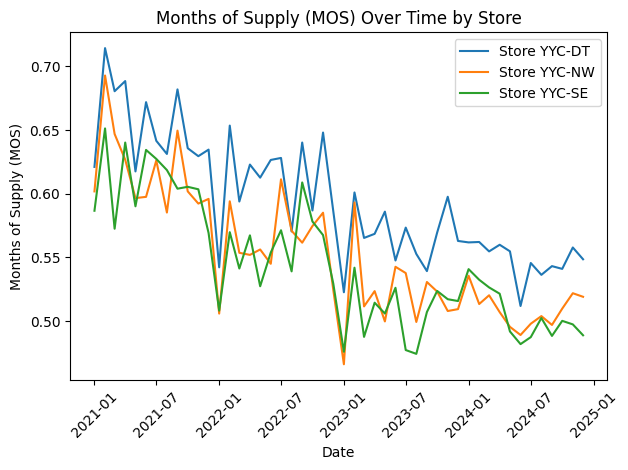

In [19]:
#Plot

plt.figure()
for store in joined_df['store_id'].unique():
    store_data = joined_df[joined_df['store_id'] == store]
    plt.plot(store_data['date'], store_data['MOS'], label=f'Store {store}')

plt.xlabel('Date')
plt.ylabel('Months of Supply (MOS)')
plt.title('Months of Supply (MOS) Over Time by Store')
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Analysis of MOS Using Month By Month Method
There is an issue as the bookstores are 'HEAVILY UNDERSTOCKED' at the moment
- What was not accounted for was previous stock as the total_qty only accounts for incoming stock and not what may have already been previously in the store
- Understocked is stores with a MOS < 1
- Properly Stocked or Healthy  MOS ~ 1 - 2
- Overstocked MOS > 3

### Cumulative Inventory
Determining Previous Stock

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Merged Datasets Again
merged_df = pd.merge(sales_df, inventory_df, on=['store_id', 'date'], how='inner')


In [21]:
## Trying to filter first may need to delete
merged_df = merged_df[merged_df['date'] >= '2021-01-01']

merged_df = merged_df.reset_index(drop=True)

In [22]:
# Units Sold Calculation
merged_df['units_sold'] = np.floor(merged_df['net_revenue'] / merged_df['wavg_unit_price'])
merged_df.head()

,date,store_id,revenue,net_revenue,total_qty,wavg_unit_price,units_sold
0,2021-01-01,YYC-DT,59255.13,56292.39,1344,26.01,2164.0
1,2021-01-01,YYC-NW,42090.52,39985.98,913,26.35,1517.0
2,2021-01-01,YYC-SE,35663.93,33880.70,765,25.98,1304.0
3,2021-02-01,YYC-DT,60306.40,57291.07,1580,25.89,2212.0
4,2021-02-01,YYC-NW,42214.89,40104.17,1087,25.56,1569.0


In [23]:
# Sorting by date
merged_df = merged_df.sort_values(['store_id', 'date'])

In [24]:
## Initializing a Running Inventory Column
merged_df['running_inventory'] = 0.0

In [25]:
## Applying for each store

for store in merged_df['store_id'].unique():
    store_data = merged_df[merged_df['store_id'] == store]
    previous_inventory = 4000.0
    runnning = []
    for index, row in store_data.iterrows():
        current_inventory = previous_inventory + row['total_qty'] - row['units_sold']
        runnning.append(current_inventory)
        previous_inventory = current_inventory
    merged_df.loc[store_data.index, 'running_inventory'] = runnning


In [26]:
merged_df["MOS"] = merged_df['running_inventory'] / merged_df['units_sold']

merged_df["MOS"] = np.floor(merged_df["MOS"])
merged_df.head(5)

,date,store_id,revenue,net_revenue,total_qty,wavg_unit_price,units_sold,running_inventory,MOS
0,2021-01-01,YYC-DT,59255.13,56292.39,1344,26.01,2164.0,3180.0,1.0
3,2021-02-01,YYC-DT,60306.40,57291.07,1580,25.89,2212.0,2548.0,1.0
6,2021-03-01,YYC-DT,70983.10,67433.94,1725,26.60,2535.0,1738.0,0.0
9,2021-04-01,YYC-DT,72715.28,69079.51,1834,25.93,2664.0,908.0,0.0
12,2021-05-01,YYC-DT,77987.76,74088.37,1747,26.18,2829.0,-174.0,-1.0


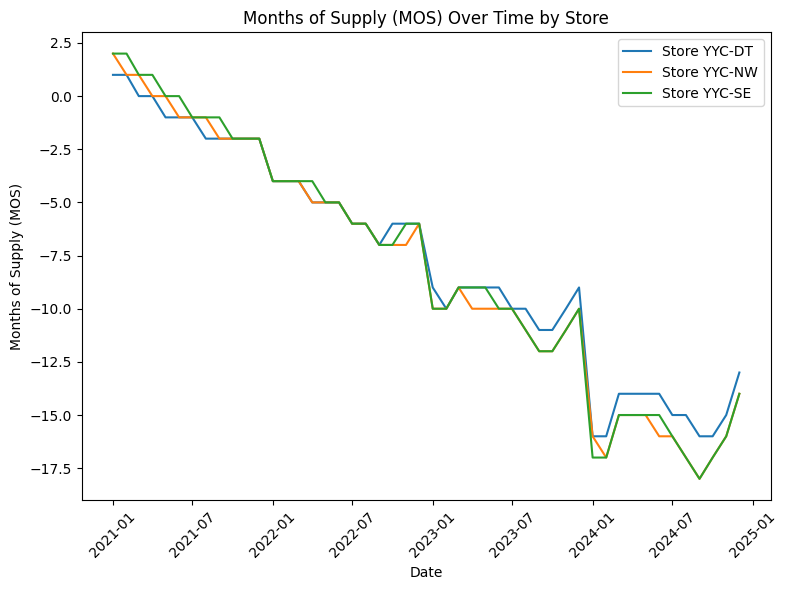

In [27]:
plt.figure(figsize=(8,6))
for store in merged_df['store_id'].unique():
    store_data = merged_df[merged_df['store_id'] == store]
    plt.plot(store_data['date'], store_data['MOS'], label=f'Store {store}')

plt.xlabel('Date')
plt.ylabel('Months of Supply (MOS)')
plt.title('Months of Supply (MOS) Over Time by Store')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Concluding Statements
- Each Store is running into stockouts
- Cumulative Inventory did not make for a better supply and or MOS
- Looking at Month by Month determined a better analysis
- Customers could be ordering online
- Stores are missing out on Sales due to stockouts
- Better Results for MOS was using Month by Month

# Model Analysis

In [28]:
# Previewing Dataframe Before Modeling
joined_df.head()

,date,store_id,revenue,net_revenue,total_qty,wavg_unit_price,units_sold,MOS
0,2021-01-01,YYC-DT,59255.13,56292.39,1344,26.01,2164.0,0.621072
1,2021-01-01,YYC-NW,42090.52,39985.98,913,26.35,1517.0,0.601846
2,2021-01-01,YYC-SE,35663.93,33880.70,765,25.98,1304.0,0.586656
3,2021-02-01,YYC-DT,60306.40,57291.07,1580,25.89,2212.0,0.714286
4,2021-02-01,YYC-NW,42214.89,40104.17,1087,25.56,1569.0,0.692798


In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [30]:
joined_df['date'] = pd.to_datetime(joined_df['date'])
df = joined_df.sort_values(['store_id', 'date'])

In [31]:
# Calculate Stock-to-Sales Ratio
## MOS =  total_qty / units_sold, Stock-to-Sales Ratio (inverse of MOS)
df['stock_to_sales_ratio'] = round(df['units_sold'] / df['total_qty'], 2)

In [32]:
# Create Lag Features
# Last month's inventory affactes this month's revenue
df['lag_total_qty'] = df.groupby('store_id')['total_qty'].shift(1)
df['lag_units_sold'] = df.groupby('store_id')['units_sold'].shift(1)

In [33]:
# One-Hot Encoding for Store ID
df = pd.get_dummies(df, columns=['store_id'], prefix='store')
# Drop rows with NaN values (due to lag features)
df = df.dropna()

In [34]:
df.head()

,date,revenue,net_revenue,total_qty,wavg_unit_price,units_sold,MOS,stock_to_sales_ratio,lag_total_qty,lag_units_sold,store_YYC-DT,store_YYC-NW,store_YYC-SE
3,2021-02-01,60306.40,57291.07,1580,25.89,2212.0,0.714286,1.40,1344.0,2164.0,True,False,False
6,2021-03-01,70983.10,67433.94,1725,26.60,2535.0,0.680473,1.47,1580.0,2212.0,True,False,False
9,2021-04-01,72715.28,69079.51,1834,25.93,2664.0,0.688438,1.45,1725.0,2535.0,True,False,False
12,2021-05-01,77987.76,74088.37,1747,26.18,2829.0,0.617533,1.62,1834.0,2664.0,True,False,False
15,2021-06-01,78194.76,74285.04,1923,25.95,2862.0,0.671908,1.49,1747.0,2829.0,True,False,False


In [35]:
features = [
    'total_qty', 'wavg_unit_price','MOS','stock_to_sales_ratio',
     'lag_total_qty', 'store_YYC-DT','store_YYC-NW','store_YYC-SE'
]

X = df[features]
y = df['net_revenue']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
# Initialize and fit the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Output Importance
importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
})
importances = importances.sort_values('Importance', ascending=False)
print(importances)


                Feature  Importance
0             total_qty    0.889379
4         lag_total_qty    0.041699
2                   MOS    0.034430
3  stock_to_sales_ratio    0.026434
1       wavg_unit_price    0.007155
7          store_YYC-SE    0.000377
6          store_YYC-NW    0.000348
5          store_YYC-DT    0.000178


In [37]:
# Predict on the test set
y_pred = rf_model.predict(X_test)
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R^2 Score:", r2_score(y_test, y_pred)) 

Root Mean Squared Error: 3643.20263523856
R^2 Score: 0.9531706705964296


In [38]:
# This tells you which variable (Supply vs Price) is driving the Revenue
importances = rf_model.feature_importances_
for i, feature in enumerate(X.columns):
    print(f"Feature: {feature}, Importance: {importances[i]:.4f}")

Feature: total_qty, Importance: 0.8894
Feature: wavg_unit_price, Importance: 0.0072
Feature: MOS, Importance: 0.0344
Feature: stock_to_sales_ratio, Importance: 0.0264
Feature: lag_total_qty, Importance: 0.0417
Feature: store_YYC-DT, Importance: 0.0002
Feature: store_YYC-NW, Importance: 0.0003
Feature: store_YYC-SE, Importance: 0.0004


In [39]:
# Predict
y_pred = rf_model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"R^2 Score: {r2:.4f}")
print(f"On average, the model is off by: ${mae:.2f} (MAE)")
print(f"Heavier penalties for large misses: ${rmse:.2f} (RMSE)")

R^2 Score: 0.9532
On average, the model is off by: $2583.84 (MAE)
Heavier penalties for large misses: $3643.20 (RMSE)


## Random Forest Conclusion
- High R^2: Over 95% means the revenue is tied to Supply
- MAE: There is noise that is not explained by price point
- RMSE: Being higher then MAE means there is other variables like seasonality
- Importance: total_qty 88.9% meaning Revenue is determined by total_qty this means there is a "Supply Limit" on revenue

# Solution to the Business Question

### Improve MOS to Prevent 'Stockouts'
- Use Prophet to determine seasonal peaks

In [40]:
joined_df.head()

,date,store_id,revenue,net_revenue,total_qty,wavg_unit_price,units_sold,MOS
0,2021-01-01,YYC-DT,59255.13,56292.39,1344,26.01,2164.0,0.621072
1,2021-01-01,YYC-NW,42090.52,39985.98,913,26.35,1517.0,0.601846
2,2021-01-01,YYC-SE,35663.93,33880.70,765,25.98,1304.0,0.586656
3,2021-02-01,YYC-DT,60306.40,57291.07,1580,25.89,2212.0,0.714286
4,2021-02-01,YYC-NW,42214.89,40104.17,1087,25.56,1569.0,0.692798


In [41]:
from prophet import Prophet # type: ignore
# Prepare data for Prophet

TARGET_MOS = 1.5
stores = joined_df['store_id'].unique() 
final_plan = []

for store in stores:
    store_data = joined_df[joined_df['store_id'] == store]
    store_data = store_data.sort_values('date')
    
    # Prepare data for Prophet
    prophet_df = store_data[['date', 'MOS']].rename(columns={'date': 'ds', 'MOS': 'y'})
    
    # Fit the model
    model = Prophet()
    model.fit(prophet_df)
    
    # Create future dataframe for next 3 months
    future = model.make_future_dataframe(periods=3, freq='M')
    
    # Predict future MOS
    forecast = model.predict(future)
    
    # Extract predictions for the next 3 months
    future_forecast = forecast[forecast['ds'] > store_data['date'].max()]
    
    # Determine if we need to order more inventory based on predicted MOS
    for index, row in future_forecast.iterrows():
        if row['yhat'] < TARGET_MOS:
            final_plan.append({
                'store_id': store,
                'date': row['ds'],
                'predicted_MOS': row['yhat'],
                'action': 'Order More Inventory'
            })
        else:
            final_plan.append({
                'store_id': store,
                'date': row['ds'],
                'predicted_MOS': row['yhat'],
                'action': 'No Action Needed'
            })

e:\Coding Programs\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
23:06:38 - cmdstanpy - INFO - Chain [1] start processing
23:06:39 - cmdstanpy - INFO - Chain [1] done processing
e:\Coding Programs\lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
23:06:39 - cmdstanpy - INFO - Chain [1] start processing
23:06:40 - cmdstanpy - INFO - Chain [1] done processing
e:\Coding Programs\lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
23:06:40 - cmdstanpy - INFO - Chain [1] start processing
23:06:40 - cmdstanpy - INFO - Chain [1]

In [42]:
plan_df = pd.DataFrame(final_plan)
print(plan_df)

  store_id       date  predicted_MOS                action
0   YYC-DT 2024-12-31       0.529108  Order More Inventory
1   YYC-DT 2025-01-31       0.523926  Order More Inventory
2   YYC-DT 2025-02-28       0.491640  Order More Inventory
3   YYC-NW 2024-12-31       0.510459  Order More Inventory
4   YYC-NW 2025-01-31       0.504567  Order More Inventory
5   YYC-NW 2025-02-28       0.443517  Order More Inventory
6   YYC-SE 2024-12-31       0.498174  Order More Inventory
7   YYC-SE 2025-01-31       0.496793  Order More Inventory
8   YYC-SE 2025-02-28       0.402811  Order More Inventory


In [43]:
from prophet import Prophet # type: ignore
import pandas as pd

# 1. Configuration
TARGET_MOS = 1.5
# List of the stores
store_list = ['YYC-DT', 'YYC-NW', 'YYC-SE'] 
results_list = []

for store in store_list:
    # 2. Prep Data for specific store
    df_p = joined_df[joined_df['store_id'] == store][['date', 'units_sold']].copy()
    df_p.columns = ['ds', 'y']
    df_p['ds'] = pd.to_datetime(df_p['ds'])

    # 3. Fit Model
    m = Prophet(yearly_seasonality=True, daily_seasonality=False, weekly_seasonality=False)
    m.fit(df_p)

    # 4. Create Future and Predict (1 month ahead)
    future = m.make_future_dataframe(periods=1, freq='MS')
    forecast = m.predict(future)

    # 5. Extract the future prediction (the very last row)
    prediction_row = forecast.tail(3) 
    predicted_sales = prediction_row['yhat'].values[0]

    # 6. Calculate Units for 1.5 MOS
    units_needed = round(predicted_sales * TARGET_MOS)

    # Store results in a dictionary
    results_list.append({
        'Store ID': store,
        'Predicted Sales': np.floor(predicted_sales),
        'Target Inventory (1.5 MOS)': units_needed
    })

# 7. Convert to DataFrame for a nice display
summary_df = pd.DataFrame(results_list)

print("--- Final Inventory Shipment Plan ---")
print(summary_df)

23:06:41 - cmdstanpy - INFO - Chain [1] start processing
23:06:41 - cmdstanpy - INFO - Chain [1] done processing
23:06:41 - cmdstanpy - INFO - Chain [1] start processing
23:06:42 - cmdstanpy - INFO - Chain [1] done processing
23:06:42 - cmdstanpy - INFO - Chain [1] start processing
23:06:42 - cmdstanpy - INFO - Chain [1] done processing


--- Final Inventory Shipment Plan ---
  Store ID  Predicted Sales  Target Inventory (1.5 MOS)
0   YYC-DT           3828.0                        5742
1   YYC-NW           2747.0                        4121
2   YYC-SE           2316.0                        3474


In [44]:
from prophet.diagnostics import cross_validation, performance_metrics # type: ignore
import logging
import warnings

# 1. Hide Prophet/CmdStanPy console logs
logger = logging.getLogger('cmdstanpy')
logger.addHandler(logging.NullHandler())
logger.propagate = False
logger.setLevel(logging.CRITICAL)

# 2. Hide general Python warnings
warnings.filterwarnings("ignore")

# Prophet Cross-Validation & Performance Metrics
# 1. Run Cross-Validation
# initial='730 days' means use 2 years to start training
# period='180 days' means test every 6 months
# horizon='365 days' means predict 1 year ahead
df_cv = cross_validation(m, initial='730 days', period='180 days', horizon='365 days')

# 2. Get Performance Metrics
df_p = performance_metrics(df_cv)
print(df_p[['horizon', 'mae', 'mape']].head())

100%|██████████| 2/2 [00:00<00:00,  2.06it/s]

  horizon         mae      mape
0 30 days  134.263108  0.078234
1 57 days  184.268213  0.102749
2 61 days  171.832415  0.092863
3 88 days  166.230566  0.092123
4 90 days  146.026545  0.074870


### Results
Prophet was the more accuracte model as the Error percentage was 7.8%

### 
|Metric|Prophet (30 Days)|
|:---|:----:|
|Average Error (MAE)|134 units|
|Error % (MAPE)|7.8%|